# Models training and tuning

We load the datasets prepared in notebook 2, define the feature set (shared by both models), and train Random Forest and XGBoost using the same methodology.

In [120]:
"""Import training and testing datasets"""
import pandas as pd

TRAINING_PATH = "../data/prepared/tennis_training.xlsx"
TESTING_PATH = "../data/prepared/tennis_testing.xlsx"
RAW_TESTING_PATH = "../data/testing/tennis_testing.xlsx"

train_set = pd.read_excel(TRAINING_PATH)
test_set = pd.read_excel(TESTING_PATH)


In [121]:
"""Feature set, shared by both models for a fair comparison."""
target = "y"

features = [
    "Rank_Diff", "Points_Diff",
    "Rank_Log_Ratio", "Points_Log_Ratio",
    # "Odds_Diff",
    "Elo_Diff", "Surface_Elo_Diff",
    "Age_Diff",
    "Recent_Form_Diff", "Recent_Surface_Form_Diff",
    "Fatigue_Diff", "Dominance_Form_Diff",
    "H2H_Diff", "H2H_Surface_Diff",
    "Left_Handed_Matchup",
    "Home_Diff",
]

X_train = train_set[features]
y_train = train_set[target]


### Why these features?

Incremental comparison using cross-validation, computed **only on the training set** (never on the test set), so this exploration does not leak into the final evaluation.

Note: this uses a small, fixed (non-tuned) Random Forest just to isolate the effect of each feature group. It runs in seconds because there is no hyperparameter search here (only 5 folds x 5 stages = 25 quick fits with shallow trees) — the real tuning happens further below with `RandomizedSearchCV`.

Base (rank, points): 66.00% (+/- 1.80%)
+ Log ratios: 66.01% (+/- 1.83%)
+ Elo: 67.81% (+/- 1.64%)
+ Form/H2H/Fatigue (our features, no odds): 68.06% (+/- 1.59%)
+ Odds (full set): 68.06% (+/- 1.59%)


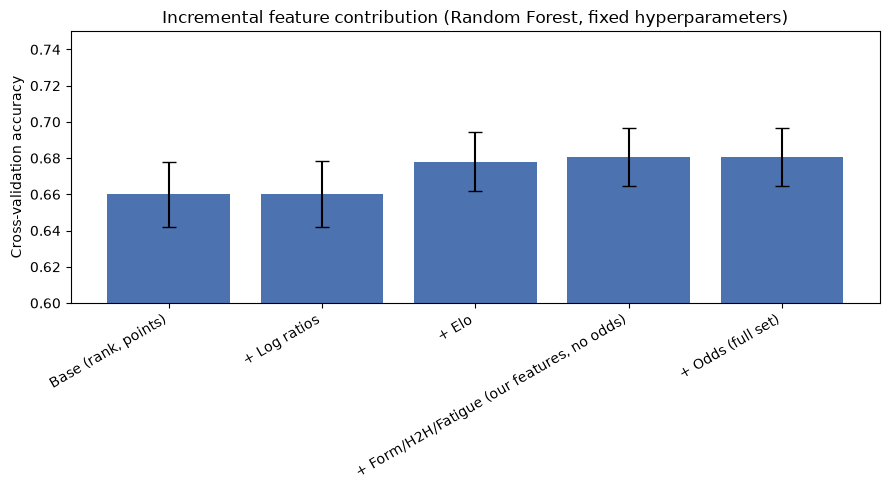

In [122]:
"""Incremental feature comparison via cross-validation (train set only)."""
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

no_odds_features = [f for f in features if f != "Odds_Diff"]

feature_stages = {
    "Base (rank, points)": ["Rank_Diff", "Points_Diff"],
    "+ Log ratios": ["Rank_Diff", "Points_Diff", "Rank_Log_Ratio", "Points_Log_Ratio"],
    "+ Elo": ["Rank_Diff", "Points_Diff", "Rank_Log_Ratio", "Points_Log_Ratio", "Elo_Diff", "Surface_Elo_Diff"],
    "+ Form/H2H/Fatigue (our features, no odds)": no_odds_features,
    "+ Odds (full set)": features,
}

time_cv = TimeSeriesSplit(n_splits=5)

stage_names, stage_means, stage_stds = [], [], []

for stage_name, feats in feature_stages.items():
    pipeline = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("num", SimpleImputer(strategy="median", add_indicator=True), feats)
        ])),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)),
    ])
    scores = cross_val_score(pipeline, train_set[feats], train_set["y"], cv=time_cv, scoring="accuracy")
    print(f"{stage_name}: {scores.mean():.2%} (+/- {scores.std():.2%})")

    stage_names.append(stage_name)
    stage_means.append(scores.mean())
    stage_stds.append(scores.std())

plt.figure(figsize=(9, 5))
plt.bar(stage_names, stage_means, yerr=stage_stds, capsize=5, color="#4C72B0")
plt.ylabel("Cross-validation accuracy")
plt.title("Incremental feature contribution (Random Forest, fixed hyperparameters)")
plt.ylim(0.6, 0.75)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Preprocessing pipeline

Same block for both models: median imputation for missing values (with a missing indicator). No scaling: neither Random Forest nor XGBoost need it.

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


def numeric_preprocessor(features):
    """Numeric preprocessing block shared by both models."""
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), features),
    ])


preprocessor = numeric_preprocessor(features)


### Random Forest

Random Forest does not require feature scaling or normalization.

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "model__n_estimators": randint(150, 400),
    "model__max_depth": randint(3, 10),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_features": ["sqrt", "log2"],
}

time_cv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=200,
    scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
    cv=time_cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit="accuracy",
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("CV accuracy:", f"{rf_search.best_score_:.2%}")


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'model__max_depth': 8, 'model__max_features': 'log2', 'model__min_samples_leaf': 19, 'model__n_estimators': 364}
CV accuracy: 68.24%


### XGBoost

Same feature set and same validation strategy (`TimeSeriesSplit`) as Random Forest, for a fair comparison.

In [125]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1,
    )),
])

param_distributions = {
    "model__n_estimators": randint(150, 800),
    "model__learning_rate": loguniform(0.01, 0.2),
    "model__max_depth": randint(1, 5),
    "model__min_child_weight": loguniform(0.5, 10),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_alpha": loguniform(1e-4, 10),
    "model__reg_lambda": loguniform(0.1, 20),
}

time_cv = TimeSeriesSplit(n_splits=5)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=200,
    scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
    cv=time_cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit="accuracy",
)

xgb_search.fit(X_train, y_train)
print("Best params:", xgb_search.best_params_)
print("CV accuracy:", f"{xgb_search.best_score_:.2%}")


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'model__colsample_bytree': np.float64(0.6859761514363028), 'model__learning_rate': np.float64(0.010979187301527605), 'model__max_depth': 4, 'model__min_child_weight': np.float64(0.8123719495141526), 'model__n_estimators': 393, 'model__reg_alpha': np.float64(0.00018077112775902955), 'model__reg_lambda': np.float64(1.3872464548825312), 'model__subsample': np.float64(0.8387371395667557)}
CV accuracy: 68.18%


### Saving the models

In [126]:
import pickle
from pathlib import Path

rf_model_path = Path("../models/random_forest_model.pkl")
xgboost_model_path = Path("../models/xgboost_model.pkl")

rf_model_path.parent.mkdir(parents=True, exist_ok=True)
xgboost_model_path.parent.mkdir(parents=True, exist_ok=True)

with rf_model_path.open("wb") as file:
    pickle.dump(rf_search.best_estimator_, file)

with xgboost_model_path.open("wb") as file:
    pickle.dump(xgb_search.best_estimator_, file)

print(f"Saved Random Forest model to {rf_model_path}")
print(f"Saved XGBoost model to {xgboost_model_path}")


Saved Random Forest model to ../models/random_forest_model.pkl
Saved XGBoost model to ../models/xgboost_model.pkl
